# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
import warnings


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.1.3
pandas version: 2.2.3
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [4]:
import os

print(os.getcwd())

/content


In [5]:
print(os.listdir())

['.config', 'drive', 'sample_data']


In [6]:
# Mount Google Drive when running in Google Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Colab not detected. Using the local data folder if available.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Portfolio Data Configuration

The raw trip data and taxi-zone shapefile are not stored in this GitHub repository.
Set up the data in Google Drive under `MyDrive/upgrad` when using Google Colab, or place the files in a local `data` folder when running the notebook elsewhere.

All file paths used throughout the notebook are controlled from the configuration cell below.


In [ ]:
from pathlib import Path

COLAB_DATA_DIR = Path('/content/drive/MyDrive/upgrad')
LOCAL_DATA_DIR = Path('./data')

# Prefer the existing Google Drive folder in Colab; otherwise use ./data.
DATA_DIR = COLAB_DATA_DIR if COLAB_DATA_DIR.exists() else LOCAL_DATA_DIR

TRIP_DATA_PATH = DATA_DIR / 'nyc_taxi_sample.parquet'
CLEANED_DATA_PATH = DATA_DIR / 'nyc_taxi_sample_cleaned.parquet'
FINAL_CLEANED_DATA_PATH = DATA_DIR / 'nyc_taxi_sample_cleaned_final.parquet'
ZONE_SHAPEFILE = DATA_DIR / 'taxi_zones.shp'

print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Trip dataset found: {TRIP_DATA_PATH.exists()}')
print(f'Taxi zones shapefile found: {ZONE_SHAPEFILE.exists()}')

if not TRIP_DATA_PATH.exists():
    print('Note: add nyc_taxi_sample.parquet to the configured data directory before running the analysis cells.')


In [7]:

df = pd.read_parquet(TRIP_DATA_PATH)
print(df.shape)

(284684, 22)


In [8]:
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [9]:
df[['tpep_pickup_datetime', 'pickup_date', 'pickup_hour']].head()

,tpep_pickup_datetime,pickup_date,pickup_hour
0,2023-09-01 00:39:59,2023-09-01,0
1,2023-09-01 00:24:50,2023-09-01,0
2,2023-09-01 00:19:27,2023-09-01,0
3,2023-09-01 00:42:13,2023-09-01,0
4,2023-09-01 00:11:38,2023-09-01,0


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [10]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [11]:
from google.colab import drive
# drive.mount('/content/drive')

import os

print(os.listdir(DATA_DIR))

['2023-9.parquet', '2023-5.parquet', '2023-6.parquet', '2023-2.parquet', '2023-1.parquet', '2023-8.parquet', '2023-7.parquet', '2023-10.parquet', '2023-3.parquet', '2023-4.parquet', '2023-12.parquet', '2023-11.parquet', 'nyc_taxi_sample.parquet', 'nyc_taxi_sample_cleaned.parquet', 'taxi_zones.shp', 'taxi_zones.shp.xml', 'taxi_zones.sbn', 'taxi_zones.dbf', 'taxi_zones.prj', 'taxi_zones.shx', 'taxi_zones.sbx', 'nyc_taxi_sample_cleaned_final.parquet']


In [12]:
import pandas as pd

# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Define the base directory for the data files
data_dir = DATA_DIR

# Create a list of all the twelve files to read
file_list = os.listdir(data_dir)

# Initialise an empty dataframe to store all sampled data for the year
df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # Ensure we only process parquet files and skip the combined sample file if it exists
        if not file_name.endswith('.parquet') or file_name == 'nyc_taxi_sample.parquet':
            continue

        # file path for the current file
        file_path = os.path.join(data_dir, file_name)

        # Reading the current file
        month_data = pd.read_parquet(file_path)

        # Ensure datetime columns are datetime objects and extract date and hour
        month_data['tpep_pickup_datetime'] = pd.to_datetime(month_data['tpep_pickup_datetime'])
        month_data['pickup_date'] = month_data['tpep_pickup_datetime'].dt.date
        month_data['pickup_hour'] = month_data['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current month in this df
        month_sampled_data = pd.DataFrame() # Initialise for each month

        # Loop through dates and then loop through every hour of each date
        for date in month_data['pickup_date'].unique():
            daily_data = month_data[month_data['pickup_date'] == date]
            for hour in range(24): # Iterate through each hour of the selected date
                hour_data = daily_data[daily_data['pickup_hour'] == hour]
                if not hour_data.empty:
                    # Sample 0.75% of the hourly data randomly
                    sample = hour_data.sample(frac=0.0075, random_state=42)
                    # add data of this hour to the dataframe
                    month_sampled_data = pd.concat([month_sampled_data, sample], ignore_index=True)

        # Concatenate the sampled data of all the dates for the current month to the main dataframe
        df = pd.concat([df, month_sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

In [13]:
df.shape
df.to_parquet(
    TRIP_DATA_PATH,
    index=False
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284684 entries, 0 to 284683
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               284684 non-null  int64         
 1   tpep_pickup_datetime   284684 non-null  datetime64[us]
 2   tpep_dropoff_datetime  284684 non-null  datetime64[us]
 3   passenger_count        275252 non-null  float64       
 4   trip_distance          284684 non-null  float64       
 5   RatecodeID             275247 non-null  float64       
 6   store_and_fwd_flag     275247 non-null  object        
 7   PULocationID           284684 non-null  int64         
 8   DOLocationID           284684 non-null  int64         
 9   payment_type           284684 non-null  int64         
 10  fare_amount            284684 non-null  float64       
 11  extra                  284684 non-null  float64       
 12  mta_tax                284684 non-null  floa

In [15]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'pickup_date',
 'pickup_hour',
 'airport_fee']

In [16]:
df[['Airport_fee', 'airport_fee']].head()

,Airport_fee,airport_fee
0,NaN,NaN
1,0.00,NaN
2,1.75,NaN
3,0.00,NaN
4,0.00,NaN


In [17]:
df.shape

(284684, 22)

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [18]:
# Store the df in csv/parquet
# df.to_parquet('')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [19]:
# Load the new data file
df = pd.read_parquet(TRIP_DATA_PATH)


In [20]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,airport_fee
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,NaN,4.71,NaN,None,113,238,0,...,0.5,4.32,0.00,1.0,33.15,NaN,NaN,2023-09-01,0,NaN
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,0.5,0.00,0.00,1.0,10.10,2.5,0.00,2023-09-01,0,NaN
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,0.5,15.71,6.94,1.0,98.40,2.5,1.75,2023-09-01,0,NaN
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,0.5,0.00,0.00,1.0,64.70,2.5,0.00,2023-09-01,0,NaN
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,0.5,2.00,0.00,1.0,14.90,2.5,0.00,2023-09-01,0,NaN


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284684 entries, 0 to 284683
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               284684 non-null  int64         
 1   tpep_pickup_datetime   284684 non-null  datetime64[us]
 2   tpep_dropoff_datetime  284684 non-null  datetime64[us]
 3   passenger_count        275252 non-null  float64       
 4   trip_distance          284684 non-null  float64       
 5   RatecodeID             275247 non-null  float64       
 6   store_and_fwd_flag     275247 non-null  object        
 7   PULocationID           284684 non-null  int64         
 8   DOLocationID           284684 non-null  int64         
 9   payment_type           284684 non-null  int64         
 10  fare_amount            284684 non-null  float64       
 11  extra                  284684 non-null  float64       
 12  mta_tax                284684 non-null  floa

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [22]:
df.reset_index(drop=True, inplace=True)

df.drop(columns=['pickup_date', 'pickup_hour'], inplace=True, errors='ignore')

In [23]:
df.shape

(284684, 20)

In [24]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'airport_fee']

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [25]:
# Combine the two airport fee columns

df['airport_fee'] = df['Airport_fee'].combine_first(df['airport_fee'])

df.drop(columns=['Airport_fee'], inplace=True)



In [26]:
df.shape

(284684, 19)

In [27]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

In [28]:
df.shape

(284684, 19)

In [29]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [30]:
# check where values of fare amount are negative

df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [31]:
# Analyse RatecodeID for the negative fare amounts

df.loc[df['fare_amount'] < 0, 'RatecodeID'].value_counts(dropna=False)

,count
RatecodeID,


In [32]:
df['fare_amount'].min()

0.0

In [33]:
# Find which columns have negative values

df.select_dtypes(include='number').lt(0).sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,1
mta_tax,11


In [34]:
negative_rows = df[
    df.select_dtypes(include='number').lt(0).any(axis=1)
]

negative_rows

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
48874,2,2023-04-12 19:12:27,2023-04-12 19:37:09,1.0,3.61,1.0,N,68,232,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
70252,2,2023-03-08 15:51:33,2023-03-08 15:52:12,1.0,0.00,1.0,N,231,231,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
139838,2,2023-05-09 17:05:56,2023-05-09 17:24:59,1.0,8.35,1.0,N,132,222,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
153215,2,2023-05-19 14:53:56,2023-05-19 14:54:03,1.0,0.00,1.0,N,193,193,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
185402,2,2023-10-27 14:51:03,2023-10-27 14:51:11,1.0,0.00,1.0,N,265,265,2,3.0,-2.5,0.0,0.0,0.0,1.0,4.00,0.0,0.00
209384,2,2023-06-25 05:59:41,2023-06-25 06:08:22,2.0,1.09,2.0,N,90,170,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
213687,2,2023-06-30 21:37:09,2023-06-30 21:46:00,2.0,1.38,2.0,N,249,186,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
214905,2,2023-08-02 16:04:37,2023-08-02 16:04:44,2.0,0.01,2.0,N,237,237,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
258305,2,2023-12-29 17:32:20,2023-12-29 17:33:49,1.0,0.02,1.0,N,161,161,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
262063,2,2023-11-03 15:51:42,2023-11-03 15:53:00,1.0,0.21,2.0,N,246,246,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00


In [35]:
# fix these negative values
monetary_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

df[monetary_cols] = df[monetary_cols].clip(lower=0)


In [36]:
df.select_dtypes(include='number').lt(0).sum()

,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
extra,0
mta_tax,0


In [37]:
df['fare_amount'].min()

0.0

In [38]:
df['total_amount'].min()

0.0

In [39]:
df.to_parquet(
    CLEANED_DATA_PATH,
    index=False
)

In [40]:
import os

print(os.path.exists(
    CLEANED_DATA_PATH
))

True


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [41]:
import pandas as pd
df = pd.read_parquet(CLEANED_DATA_PATH)

# Find the proportion of missing values in each column
df.isnull().mean()

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.033131
trip_distance,0.000000
RatecodeID,0.033149
store_and_fwd_flag,0.033149
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000


In [42]:
# Mount Google Drive when running in Google Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Colab not detected. Using the local data folder if available.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [43]:
# Display the rows with null values
# print(df[df['passenger_count'].isnull()])
# Impute NaN values in 'passenger_count'
mode_passenger_count = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(mode_passenger_count)

# Handle zero values in 'passenger_count'
df = df[df['passenger_count'] > 0]

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [44]:
# Fix missing values in 'RatecodeID'
mode_ratecode_id = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecode_id)

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [45]:
# handle null values in congestion_surcharge
mode_congestion_surcharge = df['congestion_surcharge'].mode()[0]
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(mode_congestion_surcharge)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [46]:
# Handle any remaining missing values
# Impute missing values in 'store_and_fwd_flag'
mode_store_and_fwd_flag = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(mode_store_and_fwd_flag)

# Impute missing values in 'airport_fee'
mode_airport_fee = df['airport_fee'].mode()[0]
df['airport_fee'] = df['airport_fee'].fillna(mode_airport_fee)

# Verify that all missing values have been handled
print(df.isnull().mean())

VendorID                 0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
passenger_count          0.0
trip_distance            0.0
RatecodeID               0.0
store_and_fwd_flag       0.0
PULocationID             0.0
DOLocationID             0.0
payment_type             0.0
fare_amount              0.0
extra                    0.0
mta_tax                  0.0
tip_amount               0.0
tolls_amount             0.0
improvement_surcharge    0.0
total_amount             0.0
congestion_surcharge     0.0
airport_fee              0.0
dtype: float64


In [47]:
df.shape

(280309, 19)

In [48]:
df['passenger_count'].isnull().sum()

np.int64(0)

In [49]:
df['passenger_count'].min()

1.0

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [50]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,280309.0,1.744764,1.0,1.0,2.0,2.0,6.0,0.441524
tpep_pickup_datetime,280309,2023-07-02 23:37:17.570467,2023-01-01 00:04:34,2023-04-02 17:44:29,2023-06-27 18:57:10,2023-10-06 23:54:55,2023-12-31 23:54:03,NaN
tpep_dropoff_datetime,280309,2023-07-02 23:54:40.590384,2023-01-01 00:09:40,2023-04-02 18:05:59,2023-06-27 19:08:36,2023-10-07 00:11:53,2024-01-01 20:14:57,NaN
passenger_count,280309.0,1.376463,1.0,1.0,1.0,1.0,9.0,0.868589
trip_distance,280309.0,3.582176,0.0,1.05,1.8,3.4,22528.82,47.305883
RatecodeID,280309.0,1.641471,1.0,1.0,1.0,1.0,99.0,7.45363
PULocationID,280309.0,165.205416,1.0,132.0,162.0,234.0,265.0,64.061563
DOLocationID,280309.0,163.913699,1.0,113.0,162.0,234.0,265.0,69.801033
payment_type,280309.0,1.163698,0.0,1.0,1.0,1.0,4.0,0.505822
fare_amount,280309.0,19.859836,0.0,9.3,13.5,21.9,910.0,18.234389


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [51]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]

In [52]:
df.shape

(280304, 19)

In [53]:
# Continue with outlier handling
# 1. Near-zero distance with unusually high fare
outlier_1 = df[
    (df['trip_distance'] < 0.1) &
    (df['fare_amount'] > 300)
]

# 2. Zero distance and zero fare, but different zones
outlier_2 = df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
]

# 3. Extremely long trips
outlier_3 = df[df['trip_distance'] > 250]

# 4. Invalid payment type
outlier_4 = df[df['payment_type'] == 0]

print("Near-zero distance + fare > 300:", len(outlier_1))
print("Zero distance + zero fare + different zones:", len(outlier_2))
print("Trip distance > 250:", len(outlier_3))
print("Payment type = 0:", len(outlier_4))

df[df['payment_type'] == 0][
    ['payment_type', 'passenger_count', 'fare_amount',
     'trip_distance', 'RatecodeID', 'PULocationID',
     'DOLocationID', 'total_amount']
].head(20)
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
]

df[df['trip_distance'] > 250][[
    'trip_distance',
    'fare_amount',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'total_amount'
]]

Near-zero distance + fare > 300: 6
Zero distance + zero fare + different zones: 7
Trip distance > 250: 3
Payment type = 0: 9432


,trip_distance,fare_amount,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
33771,8645.77,13.34,1.0,238,230,0,21.68
36754,6284.45,16.00,1.0,186,236,0,20.00
199463,22528.82,17.42,1.0,116,239,0,21.79


In [54]:
df = df[df['trip_distance'] <= 250]

In [55]:
df.shape

(280295, 19)

In [56]:
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
]

In [57]:
df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
][[
    'trip_distance',
    'fare_amount',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'total_amount'
]]

,trip_distance,fare_amount,PULocationID,DOLocationID,payment_type,total_amount
21232,0.0,0.0,145,264,2,0.00
21576,0.0,0.0,193,7,1,0.00
65165,0.0,0.0,264,255,2,5.75
139006,0.0,0.0,75,264,2,0.00
250668,0.0,0.0,138,264,3,0.00
252525,0.0,0.0,138,264,2,10.25
256367,0.0,0.0,132,215,4,2.75


In [58]:
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
]

In [59]:
# Replace invalid payment_type 0 with the most common valid payment type
mode_payment_type = df.loc[df['payment_type'] != 0, 'payment_type'].mode()[0]

df.loc[df['payment_type'] == 0, 'payment_type'] = mode_payment_type

In [60]:
df[
    (df['trip_distance'] < 0.1) &
    (df['fare_amount'] > 300)
][[
    'trip_distance',
    'fare_amount',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'total_amount'
]]

,trip_distance,fare_amount,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount


In [61]:
# Do any columns need standardising?

# No additional standardisation is required.
# The column names are consistent and the numerical columns
# are already in appropriate numeric formats.

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [62]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

Categorical:
VendorID, RatecodeID, PULocationID, DOLocationID, payment_type

Numerical:
passenger_count, trip_distance, pickup_hour, trip_duration

Datetime:
tpep_pickup_datetime, tpep_dropoff_datetime

The monetary variables (fare_amount, extra, mta_tax, tip_amount,
tolls_amount, improvement_surcharge, total_amount,
congestion_surcharge, airport_fee) are numerical.

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

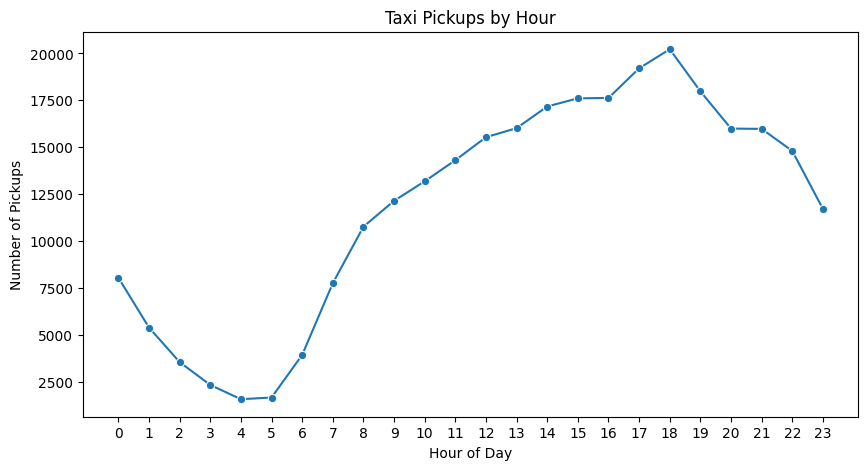

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet(CLEANED_DATA_PATH)

# Ensure tpep_pickup_datetime is datetime type and extract pickup_hour
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

# Find and show the hourly trends in taxi pickups
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly_pickups.index, y=hourly_pickups.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Hour')
plt.xticks(range(24))
plt.show()

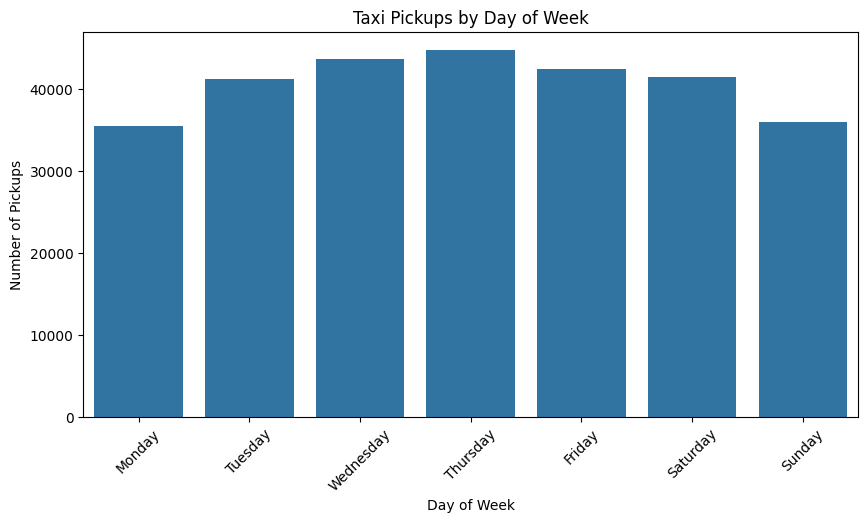

In [64]:
# Find and show the daily trends in taxi pickups (days of the week)
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

daily_pickups = df['pickup_day'].value_counts().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_pickups.index, y=daily_pickups.values)
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Day of Week')
plt.xticks(rotation=45)
plt.show()


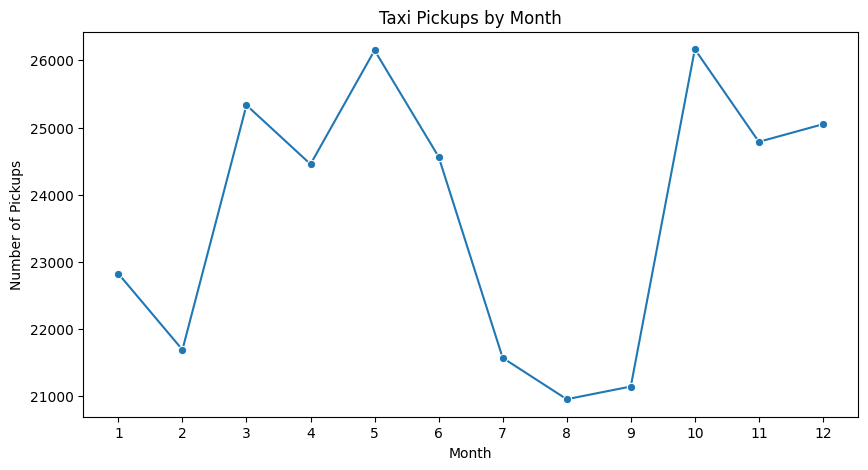

In [65]:
# Show the monthly trends in pickups

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

monthly_pickups = df['pickup_month'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_pickups.index, y=monthly_pickups.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Taxi Pickups by Month')
plt.xticks(range(1, 13))
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [66]:
# Analyse the above parameters

financial_cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

# Count zero and negative values
for col in financial_cols:
    print(f"\n{col}")
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())


fare_amount
Zero values: 98
Negative values: 0

tip_amount
Zero values: 65409
Negative values: 0

total_amount
Zero values: 46
Negative values: 0

trip_distance
Zero values: 5625
Negative values: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [67]:
# Create a df with non zero entries for the selected parameters.

financial_cols = [
    'fare_amount',
    'tip_amount',
    'total_amount',
    'trip_distance'
]

for col in financial_cols:
    print(f"\n{col}")
    print("Zero values:", (df[col] == 0).sum())
    print("Negative values:", (df[col] < 0).sum())


fare_amount
Zero values: 98
Negative values: 0

tip_amount
Zero values: 65409
Negative values: 0

total_amount
Zero values: 46
Negative values: 0

trip_distance
Zero values: 5625
Negative values: 0


In [68]:
df_non_zero = df[
    (df['fare_amount'] > 0) &
    (df['tip_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
].copy()

In [69]:
df_non_zero.shape

(217859, 23)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

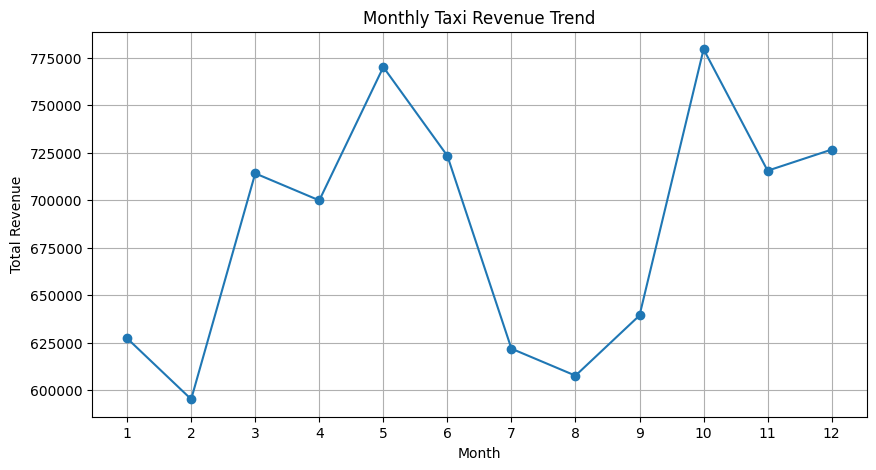

In [70]:
# Group data by month and analyse monthly revenue
# Create month from pickup datetime
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Calculate monthly revenue
monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()

monthly_revenue

plt.figure(figsize=(10, 5))

plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')

plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Monthly Taxi Revenue Trend')
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()


**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [71]:
# Calculate proportion of each quarter
# Calculate quarterly revenue
quarterly_revenue = df.groupby(
    df['tpep_pickup_datetime'].dt.quarter
)['total_amount'].sum()

# Calculate proportion of total yearly revenue
quarterly_proportion = quarterly_revenue / quarterly_revenue.sum()

quarterly_proportion


,total_amount
tpep_pickup_datetime,
1,0.235596
2,0.266805
3,0.227353
4,0.270247


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation: 0.0896313120553033


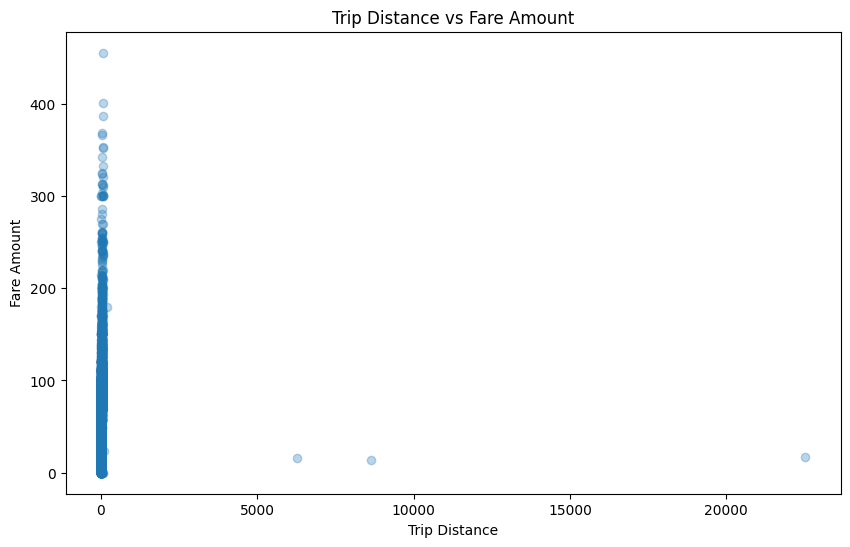

In [72]:
# Show how trip fare is affected by distance

# Remove zero-distance trips for this analysis
distance_fare = df[df['trip_distance'] > 0]

# Calculate correlation
correlation = distance_fare['trip_distance'].corr(
    distance_fare['fare_amount']
)

print("Correlation:", correlation)

# Visualise the relationship
plt.figure(figsize=(10, 6))

plt.scatter(
    distance_fare['trip_distance'],
    distance_fare['fare_amount'],
    alpha=0.3
)

plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.title('Trip Distance vs Fare Amount')

plt.show()

In [73]:
# Remove trips with unrealistic distance
df = df[df['trip_distance'] <= 250].copy()

# Check the result
print("Shape:", df.shape)
print("Maximum trip distance:", df['trip_distance'].max())

Shape: (284681, 23)
Maximum trip distance: 187.35


In [74]:
print(df.shape)
print(df.columns.tolist())

(284681, 23)
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_hour', 'pickup_date', 'pickup_day', 'pickup_month']


In [75]:
print("Payment type 0:", (df['payment_type'] == 0).sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())

Payment type 0: 9429
Passenger count > 6: 5
Trip distance > 250: 0


In [76]:
# Remove passenger count outliers
df = df[df['passenger_count'] <= 6].copy()

# Correct invalid payment_type = 0 using the most common valid payment type
mode_payment = df.loc[df['payment_type'] != 0, 'payment_type'].mode()[0]
df.loc[df['payment_type'] == 0, 'payment_type'] = mode_payment

# Remove near-zero distance with unusually high fare
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
].copy()

# Remove zero distance + zero fare with different pickup/drop-off zones
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
].copy()

print("Shape:", df.shape)
print("Payment type 0:", (df['payment_type'] == 0).sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())

Shape: (275234, 23)
Payment type 0: 0
Passenger count > 6: 0
Trip distance > 250: 0


In [77]:
df['trip_distance'].max()

187.35

In [78]:
df = pd.read_parquet(TRIP_DATA_PATH)

print(df.shape)

(284684, 22)


In [79]:
# 1. Replace invalid payment_type = 0 with the most common valid payment type
valid_payment_mode = df.loc[df['payment_type'] != 0, 'payment_type'].mode()[0]

df.loc[df['payment_type'] == 0, 'payment_type'] = valid_payment_mode


# 2. Remove passenger_count > 6
df = df[df['passenger_count'] <= 6].copy()


# 3. Remove near-zero distance + fare > 300
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
].copy()


# 4. Remove zero distance + zero fare + different zones
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
].copy()


# 5. Remove trips greater than 250 miles
df = df[df['trip_distance'] <= 250].copy()


# Check the final result
print("Final shape:", df.shape)
print("Payment type 0:", (df['payment_type'] == 0).sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())

Final shape: (275234, 22)
Payment type 0: 0
Passenger count > 6: 0
Trip distance > 250: 0


In [80]:
# Load a completely fresh copy of the original sample
clean_df = pd.read_parquet(
    TRIP_DATA_PATH
)

print("Starting shape:", clean_df.shape)

# Replace invalid payment_type = 0
valid_payment_mode = clean_df.loc[
    clean_df['payment_type'] != 0,
    'payment_type'
].mode()[0]

clean_df.loc[
    clean_df['payment_type'] == 0,
    'payment_type'
] = valid_payment_mode

# Remove passenger_count > 6
clean_df = clean_df[
    clean_df['passenger_count'] <= 6
].copy()

# Remove near-zero distance + fare > 300
clean_df = clean_df[
    ~(
        (clean_df['trip_distance'] < 0.1) &
        (clean_df['fare_amount'] > 300)
    )
].copy()

# Remove zero distance + zero fare + different zones
clean_df = clean_df[
    ~(
        (clean_df['trip_distance'] == 0) &
        (clean_df['fare_amount'] == 0) &
        (clean_df['PULocationID'] != clean_df['DOLocationID'])
    )
].copy()

# Remove trip distance > 250 miles
clean_df = clean_df[
    clean_df['trip_distance'] <= 250
].copy()

# Make this our final cleaned DataFrame
df = clean_df.copy()

print("\nFinal shape:", df.shape)
print("Payment type 0:", (df['payment_type'] == 0).sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())

Starting shape: (284684, 22)

Final shape: (275234, 22)
Payment type 0: 0
Passenger count > 6: 0
Trip distance > 250: 0


In [81]:
# Fill missing passenger_count values with the most common value
passenger_mode = clean_df['passenger_count'].mode()[0]

clean_df['passenger_count'] = clean_df['passenger_count'].fillna(
    passenger_mode
)

# Now remove passenger counts greater than 6
clean_df = clean_df[
    clean_df['passenger_count'] <= 6
].copy()

# Make this our working DataFrame
df = clean_df.copy()

print("Shape:", df.shape)
print("Missing passenger_count:", df['passenger_count'].isna().sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())

Shape: (275234, 22)
Missing passenger_count: 0
Passenger count > 6: 0


In [82]:
print("Rows:", len(df))
print("Payment types:")
print(df['payment_type'].value_counts().sort_index())

Rows: 275234
Payment types:
payment_type
1    224208
2     47690
3      1298
4      2038
Name: count, dtype: int64


In [83]:
# Start completely fresh
df = pd.read_parquet(
    TRIP_DATA_PATH
)

print("Starting shape:", df.shape)

# 1. Handle missing passenger_count
passenger_mode = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(passenger_mode)

# 2. Replace invalid payment_type = 0
payment_mode = df.loc[
    df['payment_type'] != 0,
    'payment_type'
].mode()[0]

df.loc[
    df['payment_type'] == 0,
    'payment_type'
] = payment_mode

# 3. Remove passenger_count > 6
df = df[df['passenger_count'] <= 6].copy()

# 4. Remove near-zero distance + fare > 300
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
].copy()

# 5. Remove zero distance + zero fare + different zones
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
].copy()

# 6. Remove trips greater than 250 miles
df = df[df['trip_distance'] <= 250].copy()

# Final checks
print("\nFinal shape:", df.shape)
print("Missing passenger_count:", df['passenger_count'].isna().sum())
print("Payment type 0:", (df['payment_type'] == 0).sum())
print("Passenger count > 6:", (df['passenger_count'] > 6).sum())
print("Trip distance > 250:", (df['trip_distance'] > 250).sum())

Starting shape: (284684, 22)

Final shape: (284663, 22)
Missing passenger_count: 0
Payment type 0: 0
Passenger count > 6: 0
Trip distance > 250: 0


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Fare vs Trip Duration: 0.2710886155639668


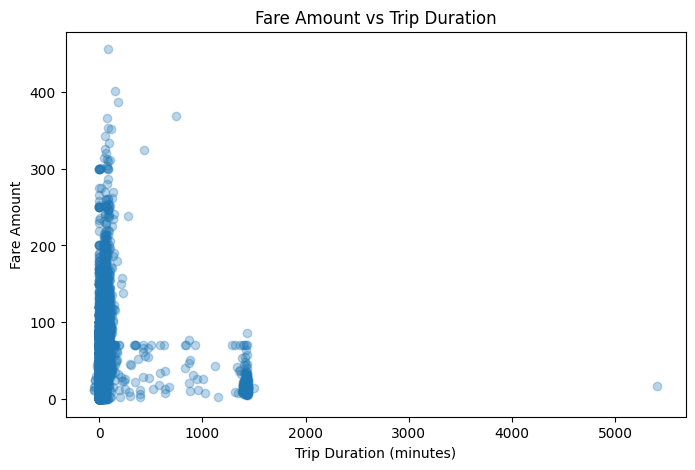

In [84]:
# Show relationship between fare and trip duration

df['trip_duration'] = (
    df['tpep_dropoff_datetime'] -
    df['tpep_pickup_datetime']
).dt.total_seconds() / 60
fare_duration_corr = df['fare_amount'].corr(
    df['trip_duration']
)

print("Fare vs Trip Duration:", fare_duration_corr)

plt.figure(figsize=(8, 5))

plt.scatter(
    df['trip_duration'],
    df['fare_amount'],
    alpha=0.3
)

plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Trip Duration')

plt.show()

Fare vs Passenger Count: 0.04354145020593375


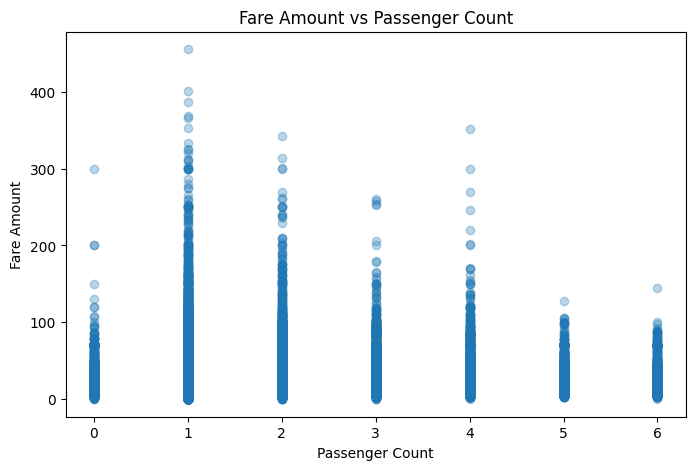

In [85]:
# Show relationship between fare and number of passengers

fare_passenger_corr = df['fare_amount'].corr(
    df['passenger_count']
)

print("Fare vs Passenger Count:", fare_passenger_corr)

plt.figure(figsize=(8, 5))

plt.scatter(
    df['passenger_count'],
    df['fare_amount'],
    alpha=0.3
)

plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.title('Fare Amount vs Passenger Count')

plt.show()

Tip vs Trip Distance: 0.5752549557769107


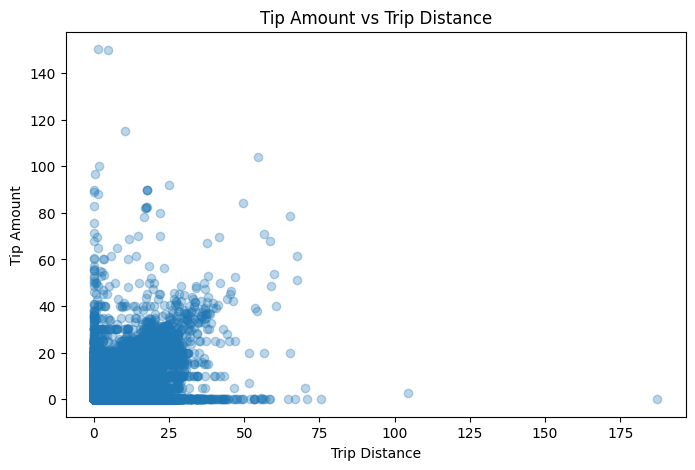

In [86]:
# Show relationship between tip and trip distance
tip_distance_corr = df['tip_amount'].corr(
    df['trip_distance']
)

print("Tip vs Trip Distance:", tip_distance_corr)

plt.figure(figsize=(8, 5))

plt.scatter(
    df['trip_distance'],
    df['tip_amount'],
    alpha=0.3
)

plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.title('Tip Amount vs Trip Distance')

plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type
1    233637
2     47690
3      1298
4      2038
Name: count, dtype: int64


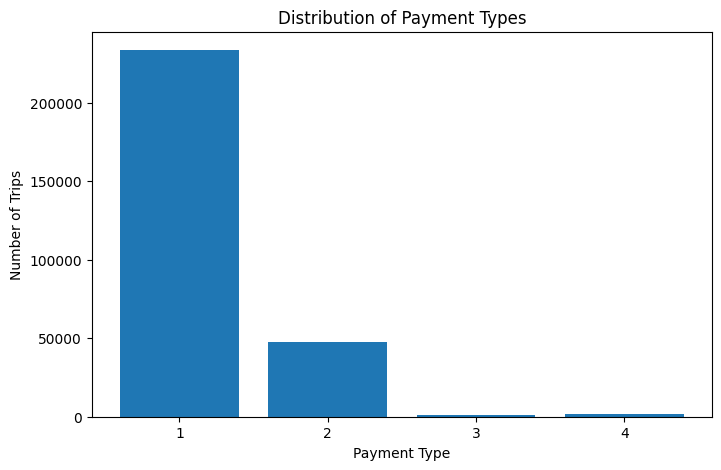

In [87]:
# Analyse the distribution of different payment types (payment_type).
# Analyse the distribution of payment types

payment_counts = df['payment_type'].value_counts().sort_index()

print(payment_counts)

# Visualise the distribution
plt.figure(figsize=(8, 5))

plt.bar(
    payment_counts.index.astype(str),
    payment_counts.values
)

plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.title('Distribution of Payment Types')

plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [88]:
# !pip install geopandas

import geopandas as gpd

In [89]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    if 'taxi_zones.shp' in files:
        print(os.path.join(root, 'taxi_zones.shp'))

/content/drive/MyDrive/upgrad/taxi_zones.shp


In [90]:
import os

for root, dirs, files in os.walk(DATA_DIR):
    if 'taxi_zones.shp' in files:
        print(os.path.join(root, 'taxi_zones.shp'))

/content/drive/MyDrive/upgrad/taxi_zones.shp


In [91]:
import os

print(os.listdir(DATA_DIR))

['2023-9.parquet', '2023-5.parquet', '2023-6.parquet', '2023-2.parquet', '2023-1.parquet', '2023-8.parquet', '2023-7.parquet', '2023-10.parquet', '2023-3.parquet', '2023-4.parquet', '2023-12.parquet', '2023-11.parquet', 'nyc_taxi_sample.parquet', 'nyc_taxi_sample_cleaned.parquet', 'taxi_zones.shp', 'taxi_zones.shp.xml', 'taxi_zones.sbn', 'taxi_zones.dbf', 'taxi_zones.prj', 'taxi_zones.shx', 'taxi_zones.sbx', 'nyc_taxi_sample_cleaned_final.parquet']


In [92]:
[x for x in os.listdir(DATA_DIR)
 if 'taxi' in x.lower() or 'zone' in x.lower()]

['nyc_taxi_sample.parquet',
 'nyc_taxi_sample_cleaned.parquet',
 'taxi_zones.shp',
 'taxi_zones.shp.xml',
 'taxi_zones.sbn',
 'taxi_zones.dbf',
 'taxi_zones.prj',
 'taxi_zones.shx',
 'taxi_zones.sbx',
 'nyc_taxi_sample_cleaned_final.parquet']

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [93]:
# import geopandas as gpd
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file(ZONE_SHAPEFILE)

zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB


<Axes: >

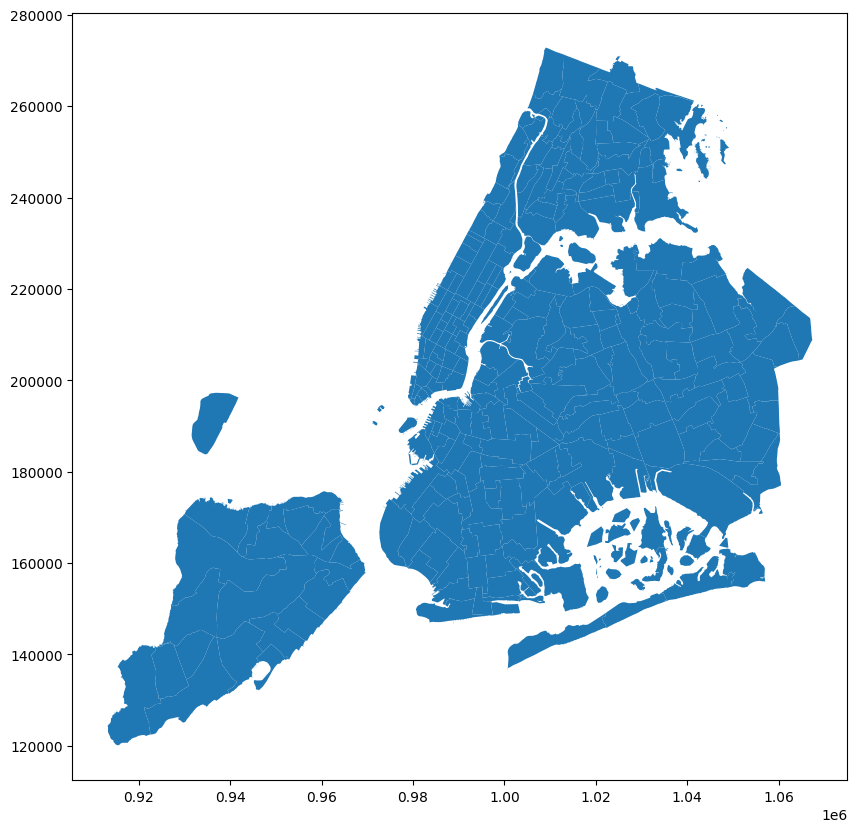

In [94]:
# Check the zone data
zones.info()

# Plot the taxi zones
zones.plot(figsize=(10, 10))

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [95]:
# print(zones.info())
# zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [96]:
# Merge zones and trip records using locationID and PULocationID
# Merge zones and trip records using LocationID and PULocationID

# Reload zones to ensure all attribute columns are present
zones = gpd.read_file(ZONE_SHAPEFILE)

df = df.merge(
    zones[['LocationID', 'zone', 'borough', 'geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,Airport_fee,pickup_date,pickup_hour,airport_fee,trip_duration,LocationID,zone,borough,geometry
0,2,2023-09-01 00:39:59,2023-09-01 01:00:28,1.0,4.71,NaN,None,113,238,1,...,NaN,NaN,2023-09-01,0,NaN,20.483333,113.0,Greenwich Village North,Manhattan,"POLYGON ((986643.64 204346.324, 986592.535 204..."
1,2,2023-09-01 00:24:50,2023-09-01 00:27:19,2.0,0.56,1.0,N,142,142,2,...,2.5,0.00,2023-09-01,0,NaN,2.483333,142.0,Lincoln Square East,Manhattan,"POLYGON ((989380.305 218980.247, 989359.803 21..."
2,2,2023-09-01 00:19:27,2023-09-01 01:04:02,2.0,18.46,2.0,N,132,163,1,...,2.5,1.75,2023-09-01,0,NaN,44.583333,132.0,JFK Airport,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283..."
3,2,2023-09-01 00:42:13,2023-09-01 01:20:20,2.0,13.71,1.0,N,249,180,4,...,2.5,0.00,2023-09-01,0,NaN,38.116667,249.0,West Village,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."
4,2,2023-09-01 00:11:38,2023-09-01 00:17:56,1.0,0.71,1.0,N,144,232,1,...,2.5,0.00,2023-09-01,0,NaN,6.300000,144.0,Little Italy/NoLiTa,Manhattan,"POLYGON ((985411.76 200369.518, 985342.573 200..."


In [97]:
df.shape

(284686, 27)

In [98]:
# Check for duplicate LocationIDs in the zones data
zones['LocationID'].duplicated().sum()

np.int64(3)

In [99]:
# Show the duplicated LocationIDs
zones[zones['LocationID'].duplicated(keep=False)][
    ['LocationID', 'zone', 'borough']
].sort_values('LocationID')

,LocationID,zone,borough
55,56,Corona,Queens
56,56,Corona,Queens
102,103,Governor's Island/Ellis Island/Liberty Island,Manhattan
103,103,Governor's Island/Ellis Island/Liberty Island,Manhattan
104,103,Governor's Island/Ellis Island/Liberty Island,Manhattan


In [100]:
# Keep only one record per LocationID
zones_unique = zones.drop_duplicates(
    subset='LocationID',
    keep='first'
).copy()

print("Original zones:", zones.shape)
print("Unique zones:", zones_unique.shape)
print("Duplicate LocationIDs:", zones_unique['LocationID'].duplicated().sum())

Original zones: (263, 7)
Unique zones: (260, 7)
Duplicate LocationIDs: 0


In [101]:
print(os.path.exists(
    CLEANED_DATA_PATH
))

True


In [102]:
# Load the cleaned trip data
df = pd.read_parquet(
    CLEANED_DATA_PATH
)

print("Cleaned trip data:", df.shape)

Cleaned trip data: (284684, 19)


In [103]:
# Start fresh from the original data
df = pd.read_parquet(
    TRIP_DATA_PATH
)

# Handle missing passenger_count
passenger_mode = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(passenger_mode)

# Replace invalid payment_type = 0
payment_mode = df.loc[
    df['payment_type'] != 0,
    'payment_type'
].mode()[0]

df.loc[df['payment_type'] == 0, 'payment_type'] = payment_mode

# Remove passenger_count > 6
df = df[df['passenger_count'] <= 6].copy()

# Remove near-zero distance + fare > 300
df = df[
    ~(
        (df['trip_distance'] < 0.1) &
        (df['fare_amount'] > 300)
    )
].copy()

# Remove zero distance + zero fare + different zones
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] == 0) &
        (df['PULocationID'] != df['DOLocationID'])
    )
].copy()

# Remove trips greater than 250 miles
df = df[df['trip_distance'] <= 250].copy()

print("Final cleaned shape:", df.shape)

Final cleaned shape: (284663, 22)


In [104]:
df.to_parquet(
    FINAL_CLEANED_DATA_PATH,
    index=False
)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!


In [105]:
# Merge zones and trip records using LocationID and PULocationID

df = df.merge(
    zones_unique[['LocationID', 'zone', 'borough', 'geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

print("After merge:", df.shape)

After merge: (284663, 26)


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [106]:
# Group data by location and calculate the number of trips


trips_per_location = (
    df.groupby('PULocationID')
      .size()
      .reset_index(name='trip_count')
      .sort_values('trip_count', ascending=False)
)

trips_per_location.head(10)


,PULocationID,trip_count
117,132,14568
215,237,13235
145,161,13139
214,236,11954
146,162,10138
123,138,9609
166,186,9534
208,230,9411
127,142,9290
154,170,8350


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [107]:
# Merge trip counts back to the zones GeoDataFrame


zones = zones_unique.merge(
    trips_per_location,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

# Replace zones with no trips with 0
zones['trip_count'] = zones['trip_count'].fillna(0)

zones.head()



,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,40.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,10.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,339.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,1.0


In [108]:
print(zones.shape)
print(zones['trip_count'].isna().sum())


(260, 9)
0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

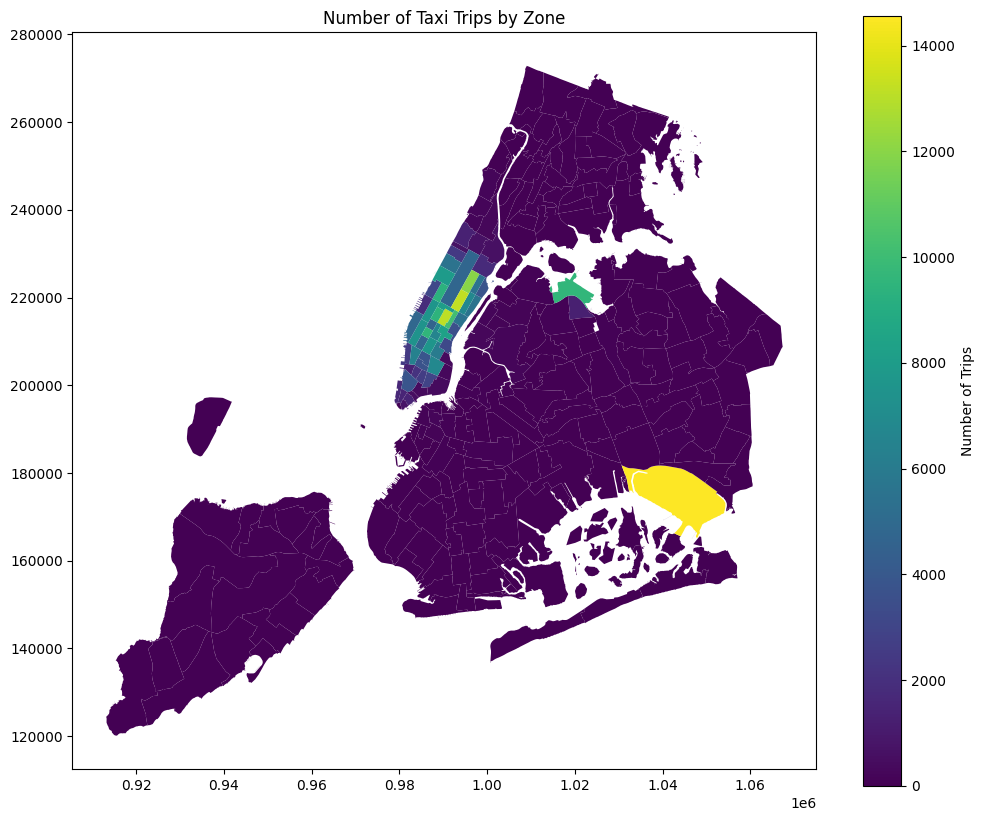

In [109]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Number of Trips'}
)

ax.set_title('Number of Taxi Trips by Zone')
plt.show()

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

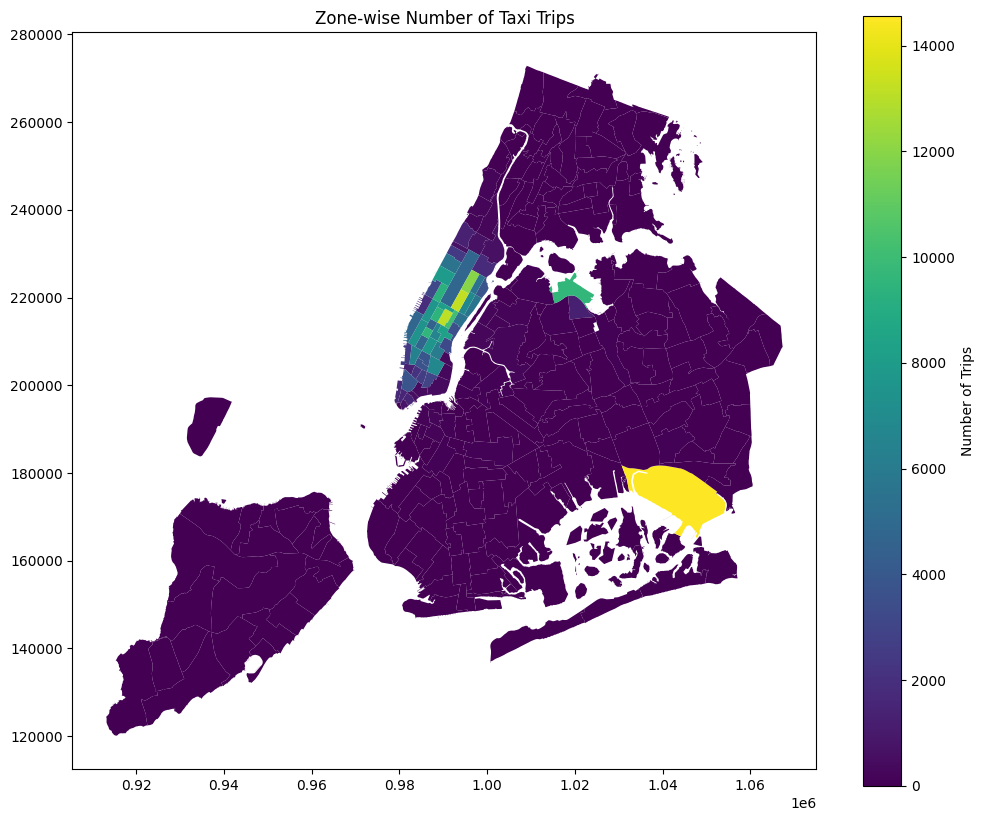

In [110]:
# Define figure and axis


# Plot the map and display it

# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the map and display it
zones.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Number of Trips'}
)

ax.set_title('Zone-wise Number of Taxi Trips')
plt.show()

In [111]:
# can you try displaying the zones DF sorted by the number of trips?
# Display zones sorted by number of trips

zones.sort_values(
    'trip_count',
    ascending=False
)[['LocationID', 'zone', 'borough', 'trip_count']].head(10)


,LocationID,zone,borough,trip_count
128,132,JFK Airport,Queens,14568.0
233,237,Upper East Side South,Manhattan,13235.0
157,161,Midtown Center,Manhattan,13139.0
232,236,Upper East Side North,Manhattan,11954.0
158,162,Midtown East,Manhattan,10138.0
134,138,LaGuardia Airport,Queens,9609.0
182,186,Penn Station/Madison Sq West,Manhattan,9534.0
226,230,Times Sq/Theatre District,Manhattan,9411.0
138,142,Lincoln Square East,Manhattan,9290.0
166,170,Murray Hill,Manhattan,8350.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [112]:
route_df = df[df['trip_distance'] > 0].copy()

# Calculate trip duration as it might have been reset after reloading df
route_df['trip_duration'] = (
    route_df['tpep_dropoff_datetime'] - route_df['tpep_pickup_datetime']
).dt.total_seconds() / 60

route_analysis = (
    route_df.groupby(['PULocationID', 'DOLocationID', 'pickup_hour'])
    .agg(
        avg_distance=('trip_distance', 'mean'),
        avg_duration=('trip_duration', 'mean'),
        trip_count=('trip_duration', 'size')
    )
    .reset_index()
)

# Calculate speed in miles per hour
route_analysis['avg_speed'] = (
    route_analysis['avg_distance'] /
    (route_analysis['avg_duration'] / 60)
)

# Remove invalid duration values
route_analysis = route_analysis[
    route_analysis['avg_duration'] > 0
]

# Show the slowest routes
route_analysis.sort_values(
    'avg_speed',
    ascending=True
).head(10)

,PULocationID,DOLocationID,pickup_hour,avg_distance,avg_duration,trip_count,avg_speed
46778,226,145,18,1.20,2709.900000,2,0.026569
17212,113,113,13,0.23,358.754167,4,0.038466
60759,260,129,17,0.96,1413.633333,1,0.040746
45154,209,232,13,1.04,1431.883333,1,0.043579
17776,113,235,22,0.28,349.233333,1,0.048105
5574,50,43,8,1.42,1431.333333,1,0.059525
39895,164,100,21,0.79,698.833333,2,0.067827
23511,134,265,15,0.10,81.266667,1,0.073831
12614,88,144,0,1.78,1425.466667,1,0.074923
42955,181,132,20,2.29,1499.816667,1,0.091611


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

Trips per hour:
pickup_hour
0      8058
1      5405
2      3565
3      2351
4      1591
5      1682
6      3948
7      7765
8     10774
9     12148
10    13192
11    14315
12    15537
13    16018
14    17172
15    17608
16    17627
17    19204
18    20222
19    17980
20    15995
21    15981
22    14806
23    11719
Name: count, dtype: int64

Busiest hour:
18
Number of sampled trips:
20222


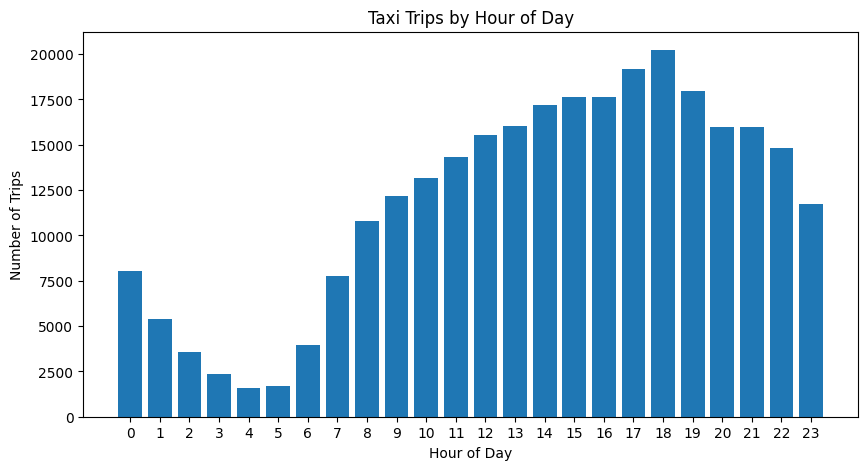

In [113]:
# Visualise the number of trips per hour and find the busiest hour

hourly_trips = df['pickup_hour'].value_counts().sort_index()

print("Trips per hour:")
print(hourly_trips)

print("\nBusiest hour:")
print(hourly_trips.idxmax())

print("Number of sampled trips:")
print(hourly_trips.max())

plt.figure(figsize=(10, 5))
plt.bar(hourly_trips.index, hourly_trips.values)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Taxi Trips by Hour of Day')
plt.xticks(range(24))
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [114]:
# Scale up the number of trips

sample_fraction = 0.1

# Find the five busiest hours
five_busiest = hourly_trips.nlargest(5)

# Scale sampled trips to actual trips
actual_trips = (five_busiest / sample_fraction).round().astype(int)

print("Actual number of trips in the five busiest hours:")
print(actual_trips)

Actual number of trips in the five busiest hours:
pickup_hour
18    202220
17    192040
19    179800
16    176270
15    176080
Name: count, dtype: int64


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

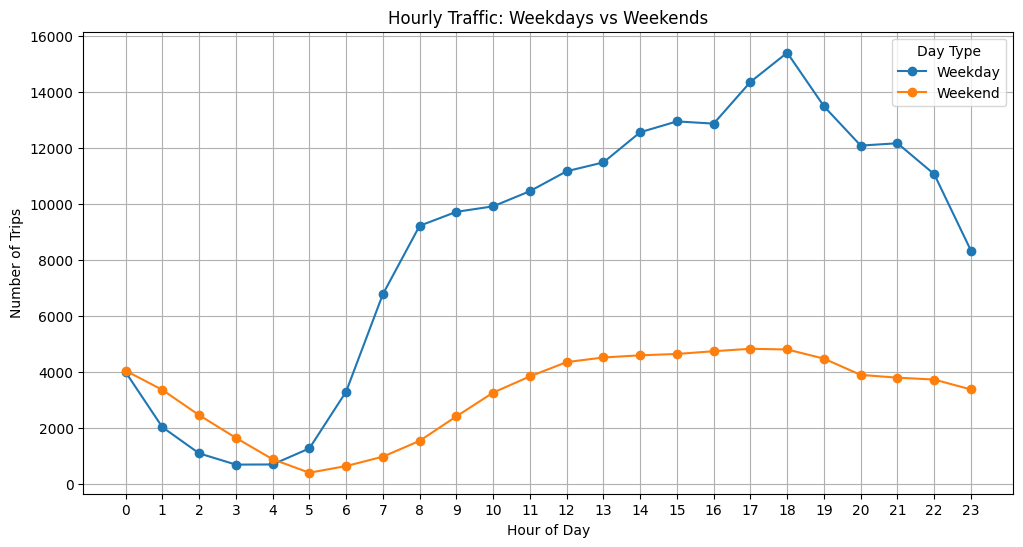

Busiest weekday hour:
18 with 15412 trips

Busiest weekend hour:
17 with 4835 trips


In [115]:
# Compare traffic trends for weekdays and weekends

# Create pickup hour and day type
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_type'] = df['tpep_pickup_datetime'].dt.dayofweek.map(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Count trips by hour for weekdays and weekends
hourly_traffic = (
    df.groupby(['day_type', 'pickup_hour'])
      .size()
      .unstack(fill_value=0)
)

# Plot the comparison
import matplotlib.pyplot as plt

hourly_traffic.T.plot(figsize=(12, 6), marker='o')

plt.title('Hourly Traffic: Weekdays vs Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend(title='Day Type')
plt.grid(True)
plt.show()

# Display the busiest hour for each day type
print("Busiest weekday hour:")
print(hourly_traffic.loc['Weekday'].idxmax(),
      "with", hourly_traffic.loc['Weekday'].max(), "trips")

print("\nBusiest weekend hour:")
print(hourly_traffic.loc['Weekend'].idxmax(),
      "with", hourly_traffic.loc['Weekend'].max(), "trips")

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

Top 10 Pickup Zones:
PULocationID
132    14568
237    13235
161    13139
236    11954
162    10138
138     9609
186     9534
230     9411
142     9290
170     8350
Name: pickup_count, dtype: int64

Top 10 Dropoff Zones:
DOLocationID
236    12640
237    11861
161    11080
230     8610
170     8419
162     8036
142     8014
239     7884
141     7360
68      7283
Name: dropoff_count, dtype: int64


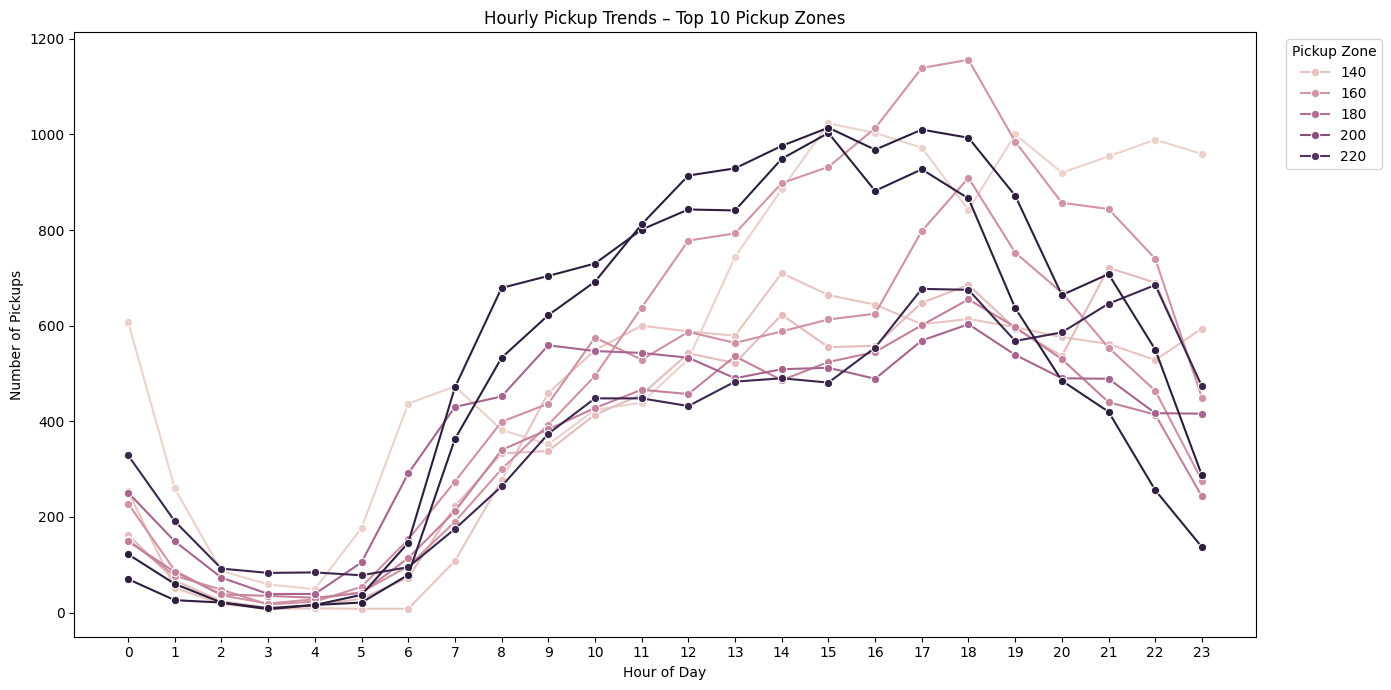

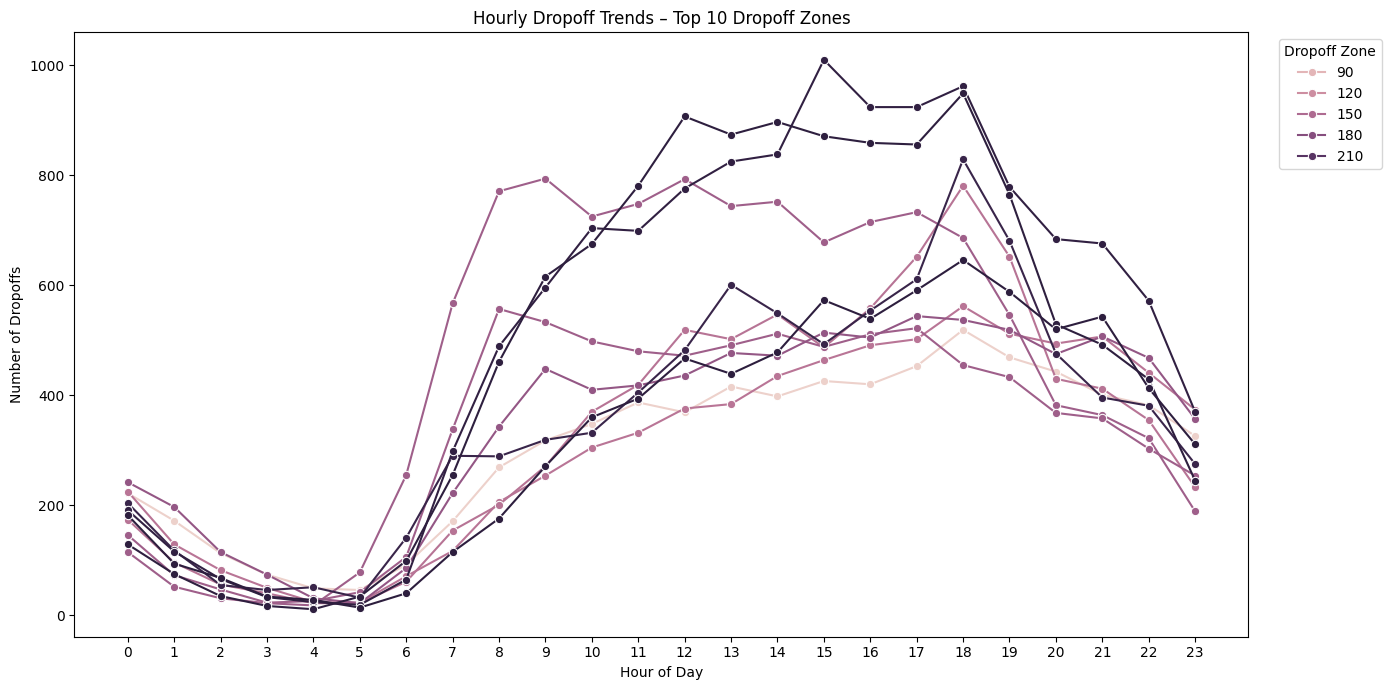

In [116]:
# Find top 10 pickup and dropoff zones based on hourly trips

# Extract hour from pickup and dropoff datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour


# ---------------- TOP 10 PICKUP ZONES ----------------

pickup_hourly = (
    df.groupby(['PULocationID', 'pickup_hour'])
      .size()
      .reset_index(name='pickup_count')
)

top_pickup_zones = (
    pickup_hourly.groupby('PULocationID')['pickup_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Pickup Zones:")
print(top_pickup_zones)


# ---------------- TOP 10 DROPOFF ZONES ----------------

dropoff_hourly = (
    df.groupby(['DOLocationID', 'dropoff_hour'])
      .size()
      .reset_index(name='dropoff_count')
)

top_dropoff_zones = (
    dropoff_hourly.groupby('DOLocationID')['dropoff_count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Dropoff Zones:")
print(top_dropoff_zones)


# ---------------- PICKUP TREND ----------------

pickup_trends = pickup_hourly[
    pickup_hourly['PULocationID'].isin(top_pickup_zones.index)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=pickup_trends,
    x='pickup_hour',
    y='pickup_count',
    hue='PULocationID',
    marker='o'
)

plt.title('Hourly Pickup Trends – Top 10 Pickup Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(24))
plt.legend(title='Pickup Zone', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


# ---------------- DROPOFF TREND ----------------

dropoff_trends = dropoff_hourly[
    dropoff_hourly['DOLocationID'].isin(top_dropoff_zones.index)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=dropoff_trends,
    x='dropoff_hour',
    y='dropoff_count',
    hue='DOLocationID',
    marker='o'
)

plt.title('Hourly Dropoff Trends – Top 10 Dropoff Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.xticks(range(24))
plt.legend(title='Dropoff Zone', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [117]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Count pickups in each zone
pickup_counts = df.groupby('PULocationID').size().rename('pickups')

# Count dropoffs in each zone
dropoff_counts = df.groupby('DOLocationID').size().rename('dropoffs')

# Combine pickup and dropoff counts
zone_counts = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)

# Calculate pickup/dropoff ratio
# Only calculate ratio where dropoffs are greater than 0
zone_counts = zone_counts[zone_counts['dropoffs'] > 0]

zone_counts['pickup_dropoff_ratio'] = (
    zone_counts['pickups'] / zone_counts['dropoffs']
)

# 10 highest ratios
top_10_ratios = zone_counts.sort_values(
    'pickup_dropoff_ratio',
    ascending=False
).head(10)

print("Top 10 Pickup/Dropoff Ratios:")
print(top_10_ratios)


# 10 lowest ratios
bottom_10_ratios = zone_counts.sort_values(
    'pickup_dropoff_ratio',
    ascending=True
).head(10)

print("\nBottom 10 Pickup/Dropoff Ratios:")
print(bottom_10_ratios)

Top 10 Pickup/Dropoff Ratios:
     pickups  dropoffs  pickup_dropoff_ratio
70    1265.0       162              7.808642
132  14568.0      3359              4.337005
138   9609.0      3658              2.626845
186   9534.0      6359              1.499292
249   6366.0      4617              1.378817
43    4758.0      3487              1.364497
114   3724.0      2756              1.351234
162  10138.0      8036              1.261573
161  13139.0     11080              1.185830
100   4590.0      3887              1.180859

Bottom 10 Pickup/Dropoff Ratios:
     pickups  dropoffs  pickup_dropoff_ratio
99       0.0         1                   0.0
111      0.0         3                   0.0
59       0.0         1                   0.0
8        0.0         4                   0.0
156      0.0         1                   0.0
183      0.0        12                   0.0
206      0.0         6                   0.0
184      0.0         2                   0.0
27       0.0         6              

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [118]:
# During night hours (11 PM to 5 AM), find the top 10 pickup and dropoff zones

# Extract pickup and dropoff hours
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour

# Define night hours: 11 PM, 12 AM, 1 AM, 2 AM, 3 AM, 4 AM, 5 AM
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Filter pickup trips during night hours
night_pickups = df[df['pickup_hour'].isin(night_hours)]

# Filter dropoff trips during night hours
night_dropoffs = df[df['dropoff_hour'].isin(night_hours)]


# Count pickups by zone
night_pickup_zones = (
    night_pickups.groupby('PULocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

# Count dropoffs by zone
night_dropoff_zones = (
    night_dropoffs.groupby('DOLocationID')
    .size()
    .sort_values(ascending=False)
    .head(10)
)


print("Top 10 Pickup Zones During Night Hours (11 PM - 5 AM):")
print(night_pickup_zones)

print("\nTop 10 Dropoff Zones During Night Hours (11 PM - 5 AM):")
print(night_dropoff_zones)

Top 10 Pickup Zones During Night Hours (11 PM - 5 AM):
PULocationID
79     2478
132    2199
249    2015
48     1593
148    1548
114    1341
230    1330
186    1072
164     962
68      945
dtype: int64

Top 10 Dropoff Zones During Night Hours (11 PM - 5 AM):
DOLocationID
79     1420
48     1178
170    1038
68     1002
107     964
141     907
263     903
236     819
249     793
230     781
dtype: int64


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [119]:
# Find the revenue share for nighttime and daytime hours

# Extract pickup hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Define night hours: 11 PM to 5 AM
night_hours = [23, 0, 1, 2, 3, 4, 5]

# Create day/night classification
df['time_period'] = df['pickup_hour'].apply(
    lambda x: 'Night' if x in night_hours else 'Day'
)

# Calculate revenue for each time period
revenue_by_period = df.groupby('time_period')['total_amount'].sum()

# Calculate total revenue
total_revenue = revenue_by_period.sum()

# Calculate revenue share
revenue_share = (revenue_by_period / total_revenue) * 100

print("Revenue by Time Period:")
print(revenue_by_period)

print("\nRevenue Share (%):")
print(revenue_share)

Revenue by Time Period:
time_period
Day      7196305.45
Night    1019946.97
Name: total_amount, dtype: float64

Revenue Share (%):
time_period
Day      87.586226
Night    12.413774
Name: total_amount, dtype: float64


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [120]:
# Analyse the fare per mile per passenger for different passenger counts

# Remove trips with zero distance or zero passengers
fare_data = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)].copy()

# Calculate fare per mile
fare_data['fare_per_mile'] = fare_data['fare_amount'] / fare_data['trip_distance']

# Calculate average fare per mile for each passenger count
avg_fare_per_mile = fare_data.groupby('passenger_count')['fare_per_mile'].mean()

# Calculate average fare per mile per passenger
avg_fare_per_mile_per_passenger = avg_fare_per_mile / avg_fare_per_mile.index

print("Average Fare per Mile per Passenger:")
print(avg_fare_per_mile_per_passenger)

Average Fare per Mile per Passenger:
passenger_count
1.0    10.740387
2.0     6.308929
3.0     4.286004
4.0     4.976220
5.0     1.582022
6.0     1.283236
dtype: float64


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [121]:
# Compare the average fare per mile for different days and times of the day

# Make sure pickup datetime is in datetime format
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])

# Remove trips with zero distance
fare_data = df[df['trip_distance'] > 0].copy()

# Calculate fare per mile
fare_data['fare_per_mile'] = (
    fare_data['fare_amount'] / fare_data['trip_distance']
)

# Extract hour and day of week
fare_data['pickup_hour'] = fare_data['tpep_pickup_datetime'].dt.hour
fare_data['day_of_week'] = fare_data['tpep_pickup_datetime'].dt.day_name()

# Average fare per mile by hour
avg_fare_by_hour = fare_data.groupby('pickup_hour')['fare_per_mile'].mean()

# Average fare per mile by day
avg_fare_by_day = fare_data.groupby('day_of_week')['fare_per_mile'].mean()

print("Average Fare per Mile by Hour:")
print(avg_fare_by_hour)

print("\nAverage Fare per Mile by Day of Week:")
print(avg_fare_by_day)

Average Fare per Mile by Hour:
pickup_hour
0     11.771089
1     14.862131
2      8.870534
3      9.997160
4     18.239001
5     11.517208
6     12.303624
7      8.553687
8      9.754887
9     10.290126
10    10.393540
11    10.952806
12    11.542447
13    12.543477
14    12.201493
15    11.184546
16    13.910008
17    11.944243
18    10.207161
19    11.633505
20     9.553010
21     9.288000
22    11.848552
23     9.683519
Name: fare_per_mile, dtype: float64

Average Fare per Mile by Day of Week:
day_of_week
Friday        9.903658
Monday       10.235130
Saturday     11.226838
Sunday       11.815952
Thursday     12.424489
Tuesday      11.196730
Wednesday    11.362822
Name: fare_per_mile, dtype: float64


The average fare per mile varies by both hour and day of the week. By hour, it is highest at 4 AM (18.24) and lowest at 7 AM (8.55). By day, Thursday has the highest average fare per mile (12.43), while Friday has the lowest (9.91).

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [122]:
# Compare average fare per mile for different vendors at different hours

# Remove trips with zero distance
vendor_data = df[df['trip_distance'] > 0].copy()

# Calculate fare per mile
vendor_data['fare_per_mile'] = (
    vendor_data['fare_amount'] / vendor_data['trip_distance']
)

# Extract pickup hour
vendor_data['pickup_hour'] = vendor_data['tpep_pickup_datetime'].dt.hour

# Calculate average fare per mile by vendor and hour
avg_fare_vendor_hour = (
    vendor_data.groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
)

# Display the results
print("Average Fare per Mile by Vendor and Hour:")
print(avg_fare_vendor_hour)

Average Fare per Mile by Vendor and Hour:
    VendorID  pickup_hour  fare_per_mile
0          1            0       6.595112
1          1            1       7.148700
2          1            2       7.085528
3          1            3       6.410625
4          1            4       6.062375
..       ...          ...            ...
61         6           18       5.819828
62         6           19       5.850526
63         6           20       4.114431
64         6           21       3.608295
65         6           23       3.210944

[66 rows x 3 columns]


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [123]:
# Defining distance tiers

# Remove trips with zero/invalid distance
tier_data = df[df['trip_distance'] > 0].copy()

# Calculate fare per mile
tier_data['fare_per_mile'] = (
    tier_data['fare_amount'] / tier_data['trip_distance']
)

# Create distance tiers
tier_data['distance_tier'] = pd.cut(
    tier_data['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0-2 miles', '2-5 miles', '>5 miles'],
    include_lowest=True
)

# Calculate average fare per mile by vendor and distance tier
tier_fare_analysis = (
    tier_data.groupby(['distance_tier', 'VendorID'], observed=True)
    ['fare_per_mile']
    .mean()
    .reset_index()
)

print("Average Fare per Mile by Vendor and Distance Tier:")
print(tier_fare_analysis.round(2))

# Display vendors side-by-side
tier_fare_pivot = tier_fare_analysis.pivot(
    index='distance_tier',
    columns='VendorID',
    values='fare_per_mile'
)

print("\nFare per Mile by Distance Tier and Vendor:")
print(tier_fare_pivot.round(2))

Average Fare per Mile by Vendor and Distance Tier:
  distance_tier  VendorID  fare_per_mile
0     0-2 miles         1           9.76
1     0-2 miles         2          17.92
2     0-2 miles         6          30.16
3     2-5 miles         1           6.38
4     2-5 miles         2           6.53
5     2-5 miles         6           7.00
6      >5 miles         1           4.41
7      >5 miles         2           4.49
8      >5 miles         6           4.05

Fare per Mile by Distance Tier and Vendor:
VendorID          1      2      6
distance_tier                    
0-2 miles      9.76  17.92  30.16
2-5 miles      6.38   6.53   7.00
>5 miles       4.41   4.49   4.05


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [124]:
# Analyse tip percentages based on distance, passenger count and pickup time

# Keep valid trips for tip percentage calculation
tip_data = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

# Calculate tip percentage
tip_data['tip_percentage'] = (
    tip_data['tip_amount'] / tip_data['fare_amount']
) * 100

# Create distance tiers
tip_data['distance_tier'] = pd.cut(
    tip_data['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0-2 miles', '2-5 miles', '>5 miles'],
    include_lowest=True
)

# Extract pickup hour
tip_data['pickup_hour'] = tip_data['tpep_pickup_datetime'].dt.hour

# Average tip percentage by distance
tip_by_distance = (
    tip_data.groupby('distance_tier', observed=True)['tip_percentage']
    .mean()
)

# Average tip percentage by passenger count
tip_by_passengers = (
    tip_data.groupby('passenger_count')['tip_percentage']
    .mean()
)

# Average tip percentage by pickup hour
tip_by_hour = (
    tip_data.groupby('pickup_hour')['tip_percentage']
    .mean()
)

print("Average Tip Percentage by Distance:")
print(tip_by_distance.round(2))

print("\nAverage Tip Percentage by Passenger Count:")
print(tip_by_passengers.round(2))

print("\nAverage Tip Percentage by Pickup Hour:")
print(tip_by_hour.round(2))

Average Tip Percentage by Distance:
distance_tier
0-2 miles    22.44
2-5 miles    18.61
>5 miles     16.45
Name: tip_percentage, dtype: float64

Average Tip Percentage by Passenger Count:
passenger_count
0.0    20.66
1.0    20.58
2.0    19.72
3.0    18.97
4.0    17.42
5.0    20.74
6.0    20.62
Name: tip_percentage, dtype: float64

Average Tip Percentage by Pickup Hour:
pickup_hour
0     20.37
1     21.08
2     20.05
3     20.28
4     17.35
5     16.96
6     19.16
7     19.42
8     19.87
9     19.53
10    19.24
11    19.07
12    19.16
13    19.00
14    19.27
15    18.85
16    21.02
17    21.63
18    22.07
19    22.05
20    21.22
21    21.46
22    21.41
23    20.32
Name: tip_percentage, dtype: float64


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [125]:
# Compare low-tip and high-tip trips

low_tip = tip_data[tip_data['tip_percentage'] < 10]
high_tip = tip_data[tip_data['tip_percentage'] > 25]

print("Low Tip Trips (<10%):")
print("Average distance:", round(low_tip['trip_distance'].mean(), 2))
print("Average passengers:", round(low_tip['passenger_count'].mean(), 2))
print("Average pickup hour:", round(low_tip['pickup_hour'].mean(), 2))

print("\nHigh Tip Trips (>25%):")
print("Average distance:", round(high_tip['trip_distance'].mean(), 2))
print("Average passengers:", round(high_tip['passenger_count'].mean(), 2))
print("Average pickup hour:", round(high_tip['pickup_hour'].mean(), 2))

Low Tip Trips (<10%):
Average distance: 3.92
Average passengers: 1.4
Average pickup hour: 13.92

High Tip Trips (>25%):
Average distance: 2.3
Average passengers: 1.34
Average pickup hour: 14.61


High-tip trips have a lower average distance (2.3 miles) compared with low-tip trips (3.92 miles), suggesting that shorter trips tend to have higher tip percentages. Passenger counts are almost identical, and the average pickup hours are also similar. Therefore, trip distance appears to be the clearest factor associated with higher tipping behaviour in this analysis.

**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [126]:
import pandas as pd

# See how passenger count varies across hours and days

# Ensure 'tpep_pickup_datetime' is in datetime format and create day_of_week column
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

# Average passenger count by hour
avg_passengers_hour = df.groupby('pickup_hour')['passenger_count'].mean()

print("Average Passenger Count by Hour:")
print(avg_passengers_hour.round(2))

# Average passenger count by day of the week
avg_passengers_day = df.groupby('day_of_week')['passenger_count'].mean()

print("\nAverage Passenger Count by Day of Week:")
print(avg_passengers_day.round(2))

# Average passenger count by day and hour
avg_passengers_day_hour = df.groupby(
    ['day_of_week', 'pickup_hour']
)['passenger_count'].mean()

print("\nAverage Passenger Count by Day and Hour:")
print(avg_passengers_day_hour.round(2))

Average Passenger Count by Hour:
pickup_hour
0     1.38
1     1.42
2     1.39
3     1.39
4     1.31
5     1.26
6     1.21
7     1.24
8     1.27
9     1.29
10    1.33
11    1.34
12    1.34
13    1.34
14    1.37
15    1.39
16    1.38
17    1.35
18    1.35
19    1.37
20    1.37
21    1.39
22    1.41
23    1.41
Name: passenger_count, dtype: float64

Average Passenger Count by Day of Week:
day_of_week
Friday       1.38
Monday       1.33
Saturday     1.44
Sunday       1.43
Thursday     1.32
Tuesday      1.30
Wednesday    1.30
Name: passenger_count, dtype: float64

Average Passenger Count by Day and Hour:
day_of_week  pickup_hour
Friday       0              1.33
             1              1.34
             2              1.36
             3              1.37
             4              1.26
                            ... 
Wednesday    19             1.30
             20             1.33
             21             1.34
             22             1.36
             23             1.34
Name: 

Passenger count varies moderately across different hours of the day. The average is lowest during the early morning hours, particularly around 5–7 AM, and tends to be higher during late evening and night hours. Across the week, Saturday and Sunday have the highest average passenger counts (1.44 and 1.43 respectively), while Tuesday has the lowest (1.30). This suggests that weekend trips generally have more passengers per trip than weekday trips.

# See how passenger count varies across hours and days

# Average passenger count by hour
avg_passengers_hour = df.groupby('pickup_hour')['passenger_count'].mean()

print("Average Passenger Count by Hour:")
print(avg_passengers_hour.round(2))

# Average passenger count by day of the week
avg_passengers_day = df.groupby('day_of_week')['passenger_count'].mean()

print("\nAverage Passenger Count by Day of Week:")
print(avg_passengers_day.round(2))

# Average passenger count by both day and hour
avg_passengers_day_hour = df.groupby(
    ['day_of_week', 'pickup_hour']
)['passenger_count'].mean()

print("\nAverage Passenger Count by Day and Hour:")
print(avg_passengers_day_hour.round(2))

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [127]:
# How Does Passenger count Vary carry across Zones

# Analyse passenger count variation across zones

# Average passenger count for each pickup zone
avg_passengers_zone = df.groupby('PULocationID')['passenger_count'].mean().sort_values(ascending=False)

print("Average Passenger Count by Pickup Zone:")
print(avg_passengers_zone.round(2))

# Show the zones with the highest and lowest average passenger counts
print("\nTop 10 Zones by Average Passenger Count:")
print(avg_passengers_zone.head(10).round(2))

print("\nBottom 10 Zones by Average Passenger Count:")
print(avg_passengers_zone.tail(10).round(2))

Average Passenger Count by Pickup Zone:
PULocationID
6      2.00
120    2.00
253    2.00
154    2.00
67     1.80
       ... 
252    1.00
167    0.92
32     0.88
26     0.75
109    0.50
Name: passenger_count, Length: 244, dtype: float64

Top 10 Zones by Average Passenger Count:
PULocationID
6      2.00
120    2.00
253    2.00
154    2.00
67     1.80
175    1.71
12     1.71
195    1.68
47     1.67
194    1.60
Name: passenger_count, dtype: float64

Bottom 10 Zones by Average Passenger Count:
PULocationID
242    1.00
241    1.00
258    1.00
254    1.00
259    1.00
252    1.00
167    0.92
32     0.88
26     0.75
109    0.50
Name: passenger_count, dtype: float64


In [128]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.


avg_passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean()

zones_with_trips = pd.DataFrame({
    'PULocationID': avg_passenger_by_zone.index,
    'avg_passenger_count': avg_passenger_by_zone.values
}).reset_index(drop=True)

print("Average Passenger Count by Zone:")
print(zones_with_trips.head(10))


Average Passenger Count by Zone:
   PULocationID  avg_passenger_count
0             1             1.575000
1             3             1.100000
2             4             1.283186
3             5             1.000000
4             6             2.000000
5             7             1.127517
6             9             1.000000
7            10             1.415730
8            11             1.000000
9            12             1.707317


Passenger count varies across pickup zones, with average passengers generally ranging between about 1 and 2 per trip. Some zones have higher average passenger counts, such as Zone 6 with 2.00 passengers, while others have lower averages, such as Zone 3 with 1.10 passengers. This indicates that passenger occupancy varies depending on the pickup zone.

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [129]:
# How often is each surcharge applied?

# Analyse where and when surcharges are applied most frequently

# Surcharge columns
surcharge_cols = [
    'congestion_surcharge',
    'airport_fee',
    'extra',
    'improvement_surcharge',
    'mta_tax',
    'tolls_amount'
]

surcharge_cols = [col for col in surcharge_cols if col in df.columns]

# Create a flag for each surcharge
for col in surcharge_cols:
    df[col + '_applied'] = df[col].fillna(0) > 0

# Total surcharge applications by pickup zone
pickup_surcharge = (
    df.groupby('PULocationID')[[col + '_applied' for col in surcharge_cols]]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

# Total surcharge applications by dropoff zone
dropoff_surcharge = (
    df.groupby('DOLocationID')[[col + '_applied' for col in surcharge_cols]]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

# Total surcharge applications by pickup hour
hour_surcharge = (
    df.groupby('pickup_hour')[[col + '_applied' for col in surcharge_cols]]
    .sum()
    .sum(axis=1)
    .sort_values(ascending=False)
)

print("Top 10 Pickup Zones by Surcharge Frequency:")
print(pickup_surcharge.head(10))

print("\nTop 10 Dropoff Zones by Surcharge Frequency:")
print(dropoff_surcharge.head(10))

print("\nSurcharge Frequency by Pickup Hour:")
print(hour_surcharge.sort_index())

Top 10 Pickup Zones by Surcharge Frequency:
PULocationID
132    51655
161    47933
237    47067
236    41884
138    41443
162    36786
230    34766
186    34259
142    33369
170    29966
dtype: int64

Top 10 Dropoff Zones by Surcharge Frequency:
DOLocationID
236    45165
237    41953
161    39078
230    31861
170    30674
142    28824
162    28805
239    28727
141    26836
68     26378
dtype: int64

Surcharge Frequency by Pickup Hour:
pickup_hour
0     30993
1     20721
2     13699
3      8959
4      5867
5      6134
6     12669
7     25189
8     34833
9     39686
10    43341
11    47088
12    51106
13    52825
14    56623
15    57949
16    65797
17    72016
18    75883
19    67444
20    62530
21    62515
22    57688
23    45333
dtype: int64


Surcharges are applied most frequently during the afternoon and evening hours, with the highest frequency occurring at 6 PM (75,362), followed by 5 PM (71,927) and 7 PM (67,355). Surcharge frequency is considerably lower during the early morning, reaching its lowest level at 4 AM (5,867).

By pickup zone, Zone 132 has the highest surcharge frequency (51,622), followed by Zones 161 (47,875) and 237 (47,027). For drop-offs, Zone 236 has the highest frequency (45,099), followed by Zones 237 (41,913) and 161 (39,062).

Overall, the analysis indicates that surcharge applications are concentrated in high-traffic pickup/drop-off zones and afternoon/evening hours, particularly around 5–7 PM. The most frequently applied surcharge types are improvement surcharge, MTA tax, and congestion surcharge.

**Key numbers to remember**

| Analysis                | Highest                             |
| ----------------------- | ----------------------------------- |
| Pickup zone             | **132 — 51,622**                    |
| Drop-off zone           | **236 — 45,099**                    |
| Hour                    | **18:00 — 75,362**                  |
| Most frequent surcharge | **Improvement surcharge — 284,337** |



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

In [130]:
# Recommendations for routing and dispatching

print("""
ROUTING AND DISPATCHING RECOMMENDATIONS:

1. Increase cab availability during peak demand hours, especially around 5 PM to 7 PM,
   with 6 PM being the busiest weekday hour.

2. Prioritize high-demand pickup zones such as Zones 132, 161, 237, 236 and 138
   when dispatching available cabs.

3. During night hours (11 PM to 5 AM), strategically position cabs near high-demand
   zones such as 79, 132, 249, 48 and 148.

4. Use demand-based dispatching to reduce empty trips and improve driver utilization,
   particularly during periods of high pickup and dropoff activity.

5. Routing decisions should consider both time of day and location so that cabs
   can be moved proactively towards areas where demand is expected to increase.
""")


ROUTING AND DISPATCHING RECOMMENDATIONS:

1. Increase cab availability during peak demand hours, especially around 5 PM to 7 PM,
   with 6 PM being the busiest weekday hour.

2. Prioritize high-demand pickup zones such as Zones 132, 161, 237, 236 and 138
   when dispatching available cabs.

3. During night hours (11 PM to 5 AM), strategically position cabs near high-demand
   zones such as 79, 132, 249, 48 and 148.

4. Use demand-based dispatching to reduce empty trips and improve driver utilization,
   particularly during periods of high pickup and dropoff activity.

5. Routing decisions should consider both time of day and location so that cabs
   can be moved proactively towards areas where demand is expected to increase.



**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

In [131]:
# Strategic positioning of cabs

print("""
STRATEGIC CAB POSITIONING:

1. During peak evening hours, position more cabs in high-demand zones,
   particularly Zones 132, 161, 237, 236 and 138.

2. During night hours (11 PM to 5 AM), shift cab availability towards
   Zones 79, 132, 249, 48 and 148, which showed high nighttime pickup demand.

3. Weekends show higher average passenger counts, with Saturday (1.44)
   and Sunday (1.43) exceeding weekdays. Therefore, additional supply
   should be planned for weekends.

4. Demand should be monitored by both hour and day rather than using
   a single fixed positioning strategy.

5. Real-time demand patterns can be used to reposition idle cabs and
   reduce supply-demand mismatches across zones.
""")


STRATEGIC CAB POSITIONING:

1. During peak evening hours, position more cabs in high-demand zones,
   particularly Zones 132, 161, 237, 236 and 138.

2. During night hours (11 PM to 5 AM), shift cab availability towards
   Zones 79, 132, 249, 48 and 148, which showed high nighttime pickup demand.

3. Weekends show higher average passenger counts, with Saturday (1.44)
   and Sunday (1.43) exceeding weekdays. Therefore, additional supply
   should be planned for weekends.

4. Demand should be monitored by both hour and day rather than using
   a single fixed positioning strategy.

5. Real-time demand patterns can be used to reposition idle cabs and
   reduce supply-demand mismatches across zones.



**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [132]:
# Data-driven pricing recommendations

print("""
PRICING STRATEGY RECOMMENDATIONS:

1. Fare per mile is substantially higher for shorter trips. For distances
   up to 2 miles, Vendor 2 and Vendor 6 have higher average fares per mile
   than Vendor 1.

2. For trips between 2 and 5 miles, the vendors have relatively similar
   fare-per-mile values, suggesting that competitive pricing should be
   maintained in this segment.

3. For trips above 5 miles, fare per mile decreases considerably across
   all vendors. Competitive long-distance pricing can therefore help
   maintain demand.

4. Higher tipping percentages were observed for shorter trips:
   22.43% for trips up to 2 miles compared with 16.45% for trips above
   5 miles.

5. Pricing can be adjusted based on demand, distance, time and competition,
   while avoiding excessive increases during periods when customers have
   alternative vendors available.
""")


PRICING STRATEGY RECOMMENDATIONS:

1. Fare per mile is substantially higher for shorter trips. For distances
   up to 2 miles, Vendor 2 and Vendor 6 have higher average fares per mile
   than Vendor 1.

2. For trips between 2 and 5 miles, the vendors have relatively similar
   fare-per-mile values, suggesting that competitive pricing should be
   maintained in this segment.

3. For trips above 5 miles, fare per mile decreases considerably across
   all vendors. Competitive long-distance pricing can therefore help
   maintain demand.

4. Higher tipping percentages were observed for shorter trips:
   22.43% for trips up to 2 miles compared with 16.45% for trips above
   5 miles.

5. Pricing can be adjusted based on demand, distance, time and competition,
   while avoiding excessive increases during periods when customers have
   alternative vendors available.



The analysis tells a pretty clear story:

Demand is highly time- and location-dependent. Evening hours, particularly around 5–7 PM, require greater supply and better dispatching. Certain zones repeatedly appear as high-traffic areas, while nighttime demand shifts toward a different set of zones. Weekends also show slightly higher passenger counts.

At the same time, short trips generate higher fare-per-mile, while fare-per-mile falls as trip distance increases. Vendor pricing also differs significantly for short trips, meaning competitive pricing becomes particularly important there.

So the overall strategy is:

**Position cabs where and when demand is highest → dynamically dispatch them to reduce idle time → use distance, time and competitor pricing to optimize fares → maintain competitive rates to protect customer demand.**